<a href="https://colab.research.google.com/github/shagun322/PYTHON-PBL/blob/main/pbl_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n_regions = 2000
data = {
    'rainfall': np.random.uniform(400, 2000, n_regions),
    'temp': np.random.uniform(15, 35, n_regions),
    'soil_moisture': np.random.uniform(10, 50, n_regions),
    'soil_ph': np.random.uniform(5.5, 8.5, n_regions),
    'nitrogen': np.random.uniform(20, 100, n_regions),
    'phosphorus': np.random.uniform(10, 60, n_regions),
    'potassium': np.random.uniform(100, 300, n_regions),
    'irrigation': np.random.uniform(0, 100, n_regions),
    'crop_area': np.random.uniform(500, 5000, n_regions),
    'fertilizer': np.random.uniform(50, 250, n_regions),
    'pesticide': np.random.uniform(1, 10, n_regions),
    'sunlight': np.random.uniform(4, 10, n_regions),
    'humidity': np.random.uniform(30, 90, n_regions),
    'altitude': np.random.uniform(0, 2000, n_regions),
    'wind_speed': np.random.uniform(5, 25, n_regions),
    'groundwater': np.random.uniform(5, 50, n_regions),
    'diversity_index': np.random.uniform(0.1, 0.9, n_regions),
    'mechanization': np.random.uniform(0, 100, n_regions),
    'yield_variance': np.random.uniform(0.05, 0.5, n_regions),
    'avg_yield': np.random.uniform(1, 8, n_regions)
}
df = pd.DataFrame(data)
df

,rainfall,temp,soil_moisture,soil_ph,nitrogen,phosphorus,potassium,irrigation,crop_area,fertilizer,pesticide,sunlight,humidity,altitude,wind_speed,groundwater,diversity_index,mechanization,yield_variance,avg_yield
0,999.264190,20.234114,32.879835,7.444771,77.621434,28.682041,230.861264,7.317510,519.807241,179.138134,7.569985,8.587816,71.131681,121.140166,19.917591,33.716506,0.121326,53.340032,0.462467,2.889908
1,1921.142890,19.939576,42.217293,6.017159,74.982640,26.645605,116.006514,8.947838,501.485717,130.483699,2.660608,4.039098,58.054258,406.415187,10.241419,25.668160,0.106368,53.675624,0.477596,5.645754
2,1571.190307,33.125092,40.406437,8.117184,27.660336,18.807696,148.465962,65.197371,2625.185574,144.381822,4.119757,6.862300,33.342414,982.526512,18.082912,48.402434,0.279500,75.972080,0.051985,3.599502
3,1357.853575,19.990924,16.155996,7.339349,93.805792,40.363334,254.735869,48.694071,631.821673,193.344957,6.969526,8.763426,85.110609,736.300465,18.983978,14.854030,0.739457,81.703086,0.192684,2.532670
4,649.629825,20.438995,15.969979,5.971612,65.477776,33.831208,205.737171,79.041525,4885.396491,225.261206,5.338804,7.780268,88.819748,821.824586,11.902369,31.453539,0.823798,33.719544,0.426820,3.860403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1451.128250,23.842141,37.377414,6.319479,88.612479,10.232224,184.867628,0.759142,3298.352385,225.407726,5.123245,9.479828,51.250181,431.976387,24.045509,30.114346,0.720688,24.039006,0.096914,6.278237
1996,1930.583394,21.688024,30.128817,6.128558,91.800707,53.683433,283.138270,57.267058,3922.394909,59.362791,7.177907,6.570839,87.121457,1620.478926,19.956484,42.767753,0.700623,3.409636,0.350506,6.351689
1997,510.332826,22.891446,40.605954,6.865986,95.736633,25.366259,199.587611,71.718689,3765.613320,110.739694,7.677700,6.267196,71.943955,565.743316,5.389117,39.330901,0.356783,72.672862,0.324190,2.886986
1998,491.287554,25.598812,29.411625,8.225313,51.799039,56.929443,179.767323,74.508017,3614.138128,138.664001,8.009863,5.387919,75.296350,68.979439,13.020097,10.339514,0.705544,23.347617,0.371013,4.040238


EDA ANALYSIS


In [ ]:
#BASIC DATA INFORMATION
print(df.head())
print(df.tail())
print(df.info())

#SHAPE AND SIZE
print(df.shape)
print(df.size)

#NULL VALUES
print(df.isna().sum())
# Fill null values with the mean of their respective columns
df = df.fillna(df.mean())

      rainfall       temp  soil_moisture   soil_ph   nitrogen  phosphorus  \
0   999.264190  20.234114      32.879835  7.444771  77.621434   28.682041   
1  1921.142890  19.939576      42.217293  6.017159  74.982640   26.645605   
2  1571.190307  33.125092      40.406437  8.117184  27.660336   18.807696   
3  1357.853575  19.990924      16.155996  7.339349  93.805792   40.363334   
4   649.629825  20.438995      15.969979  5.971612  65.477776   33.831208   

    potassium  irrigation    crop_area  fertilizer  pesticide  sunlight  \
0  230.861264    7.317510   519.807241  179.138134   7.569985  8.587816   
1  116.006514    8.947838   501.485717  130.483699   2.660608  4.039098   
2  148.465962   65.197371  2625.185574  144.381822   4.119757  6.862300   
3  254.735869   48.694071   631.821673  193.344957   6.969526  8.763426   
4  205.737171   79.041525  4885.396491  225.261206   5.338804  7.780268   

    humidity    altitude  wind_speed  groundwater  diversity_index  \
0  71.131681  12

In [ ]:
# Verify that there are no more null values
print(df.isnull().sum().sum())

0


CORELATION ACROSS REGIONS

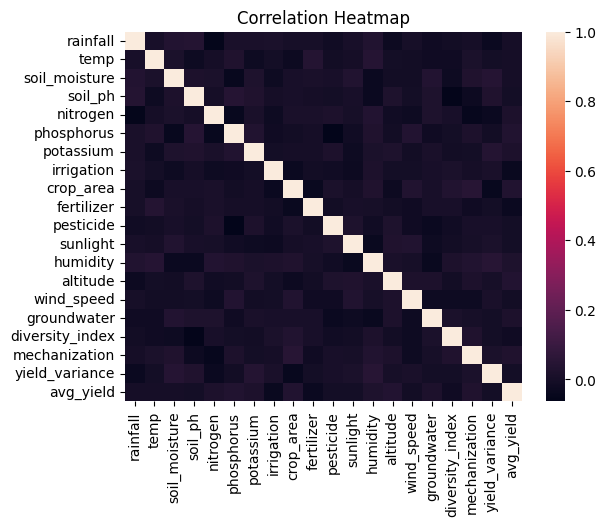

In [ ]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

DATA NORMALIZATION [MIN-MAX SCALER]

In [ ]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df)
df_normalized = pd.DataFrame(scaled_array, columns=df.columns)
print(df_normalized)

      rainfall      temp  soil_moisture   soil_ph  nitrogen  phosphorus  \
0    -0.424789 -0.813443       0.263005  0.558473  0.810430   -0.452705   
1     1.547480 -0.864488       1.073917 -1.098213  0.693504   -0.592566   
2     0.798791  1.420635       0.916653  1.338781 -1.403375   -1.130871   
3     0.342378 -0.855589      -1.189378  0.436135  1.527568    0.349562   
4    -1.172797 -0.777936      -1.205532 -1.151069  0.272338   -0.099062   
...        ...       ...            ...       ...       ...         ...   
1995  0.541930 -0.188152       0.653597 -0.747383  1.297449   -1.719832   
1996  1.567677 -0.561473       0.024093 -0.968939  1.438722    1.264382   
1997 -1.470809 -0.352913       0.933980 -0.113183  1.613125   -0.680431   
1998 -1.511555  0.116289      -0.038192  1.464260 -0.333775    1.487317   
1999 -0.740917 -1.161227      -1.205073 -1.334619 -0.973079   -0.647396   

      potassium  irrigation  crop_area  fertilizer  pesticide  sunlight  \
0      0.546143   -1.463

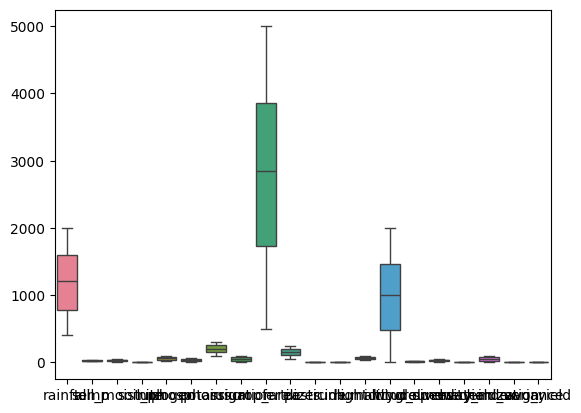

In [ ]:
import seaborn as sns
sns.boxplot(df)
plt.show()

FORWARD/BACKWARD FEATURE SELECTION

In [ ]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
model = LinearRegression()
fs = SequentialFeatureSelector(model, n_features_to_select=3, direction='backward')
fs.fit(x, y)

SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=3)

K-CLUSTERING

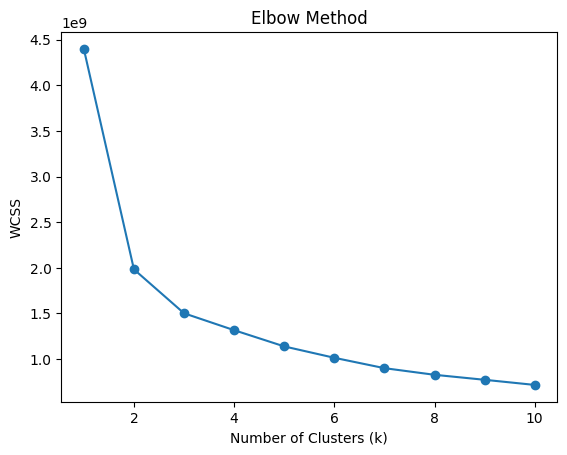

In [ ]:
X = df.values
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

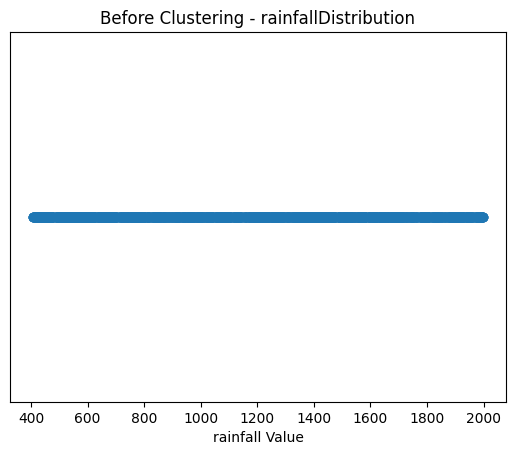

In [ ]:
# before clustering
plt.figure()
#to plot 'rainfall'
plt.scatter(df['rainfall'], [0]*len(df))
plt.title("Before Clustering - rainfallDistribution")
plt.xlabel("rainfall Value")
plt.yticks([])
plt.show()

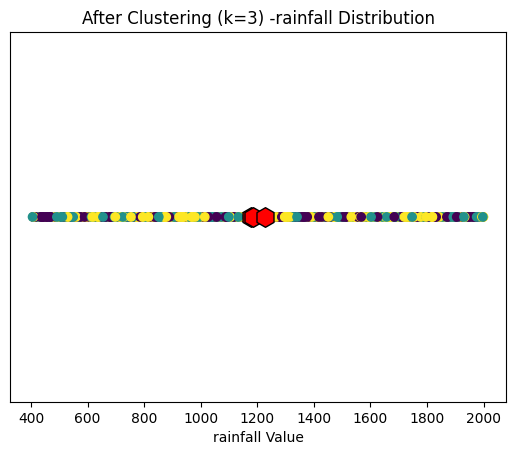

In [ ]:
# After clustering
plt.figure()

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_final.fit(X)
df['Cluster'] = kmeans_final.labels_
#cluster centroids
centroids = kmeans_final.cluster_centers_
plt.scatter(df["rainfall"], [0]*len(df), c=df["Cluster"])
plt.scatter(centroids[:, 0], [0]*len(centroids), marker='h', s=200, color='red', edgecolors='black')

plt.title(f"After Clustering (k={optimal_k}) -rainfall Distribution")
plt.xlabel("rainfall Value")
plt.yticks([])
plt.show()


In [ ]:
print("\nClustered Data:")
print(df)
wcss


Clustered Data:
         rainfall       temp  soil_moisture   soil_ph   nitrogen  phosphorus  \
0      999.264190  20.234114      32.879835  7.444771  77.621434   28.682041   
1     1921.142890  19.939576      42.217293  6.017159  74.982640   26.645605   
2     1571.190307  33.125092      40.406437  8.117184  27.660336   18.807696   
3     1357.853575  19.990924      16.155996  7.339349  93.805792   40.363334   
4      649.629825  20.438995      15.969979  5.971612  65.477776   33.831208   
...           ...        ...            ...       ...        ...         ...   
1995  1451.128250  23.842141      37.377414  6.319479  88.612479   10.232224   
1996  1930.583394  21.688024      30.128817  6.128558  91.800707   53.683433   
1997   510.332826  22.891446      40.605954  6.865986  95.736633   25.366259   
1998   491.287554  25.598812      29.411625  8.225313  51.799039   56.929443   
1999   851.499320  18.227347      15.975265  5.813441  37.371232   25.847264   

       potassium  irri

[4399501289.515024,
 1983021122.7322812,
 1501636028.5131912,
 1316226473.585305,
 1138377563.8772855,
 1013556707.5880744,
 899881405.6823734,
 827136870.2119414,
 772342695.1785914,
 716176179.1919284]

SILHOUETTE SCORE

In [ ]:
silhouette_avg = silhouette_score(X, df['Cluster'])
print(f"The average silhouette score is: {silhouette_avg}")

The average silhouette score is: 0.32050882786491014


 PCA FOR 2D VISUALIZATION

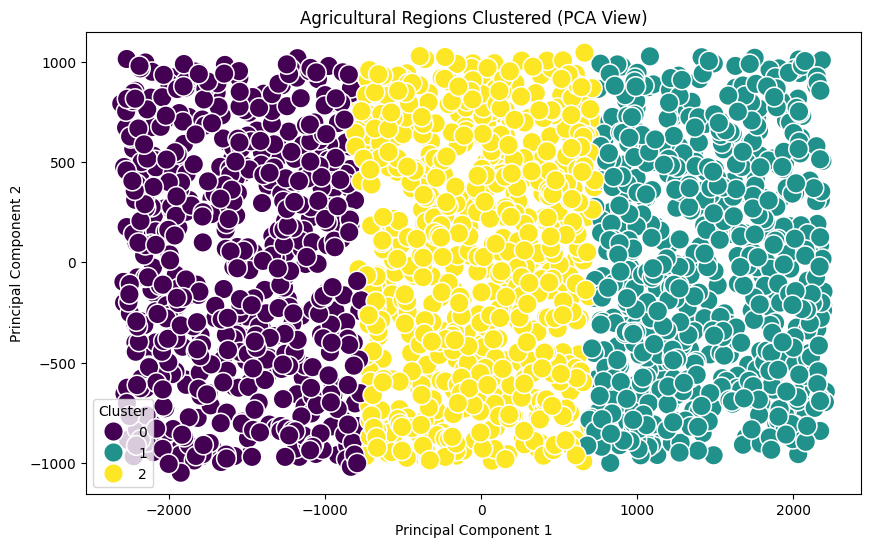

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['Cluster'], palette='viridis', s=200)
plt.title('Agricultural Regions Clustered (PCA View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

MEAN CHARACTERISTIC OF EACH CLUSTER

In [ ]:
print("\n--- Cluster Profiles (Mean Values) ---")
print(df.groupby('Cluster').mean(numeric_only=True))


--- Cluster Profiles (Mean Values) ---
            rainfall       temp  soil_moisture   soil_ph   nitrogen  \
Cluster                                                               
0        1177.474614  25.281745      29.892802  6.944636  58.675598   
1        1185.008314  24.950909      30.211134  6.953069  59.351830   
2        1227.522132  24.599324      29.476493  6.989732  59.881197   

         phosphorus   potassium  irrigation    crop_area  fertilizer  \
Cluster                                                                
0         35.499716  200.788138   51.437103  1250.185354  154.633064   
1         35.197288  200.342567   49.404898  4250.758093  148.625266   
2         35.149521  196.477087   48.737403  2770.173664  154.612664   

         pesticide  sunlight   humidity     altitude  wind_speed  groundwater  \
Cluster                                                                         
0         5.510162  7.056732  59.832888   996.755551   14.470247    27.297781   


PREDICTED CLUSTER

In [ ]:
predicted_clusters = kmeans_final.predict(X)
df['Predicted_Cluster_Label'] = predicted_clusters
print("DataFrame with Predicted Cluster Labels:")
print(df[['rainfall', 'avg_yield', 'Cluster', 'Predicted_Cluster_Label']].head())

DataFrame with Predicted Cluster Labels:
      rainfall  avg_yield  Cluster  Predicted_Cluster_Label
0   999.264190   2.889908        0                        0
1  1921.142890   5.645754        0                        0
2  1571.190307   3.599502        2                        2
3  1357.853575   2.532670        0                        0
4   649.629825   3.860403        1                        1
